They say comparison is the thief of joy, but I was robbed of that long ago so let's compare our two models.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import mediapipe as mp

df_yolo = pd.read_csv("../data/yolo_keypoints.csv")
df_mp = pd.read_csv("../data/mediapipe_keypoints.csv")

## Visualization

### Hip

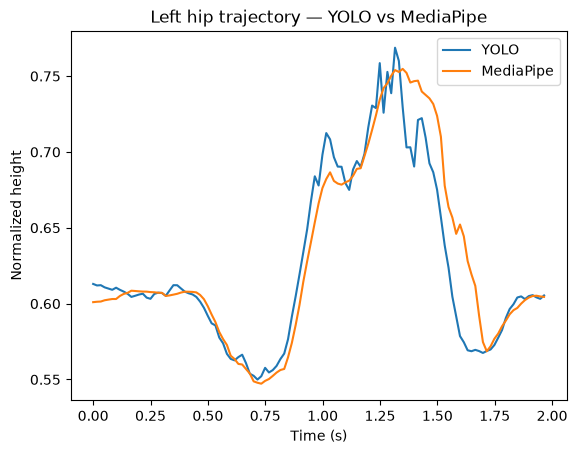

In [2]:
yolo_hip = df_yolo[df_yolo["keypoint"] == "right_hip"]
mp_hip = df_mp[df_mp["keypoint"] == "right_hip"]

plt.plot(
    yolo_hip["time"],
    1 - yolo_hip["y"],
    label="YOLO"
)

plt.plot(
    mp_hip["time"],
    1 - mp_hip["y"],
    label="MediaPipe"
)

plt.xlabel("Time (s)")
plt.ylabel("Normalized height")
plt.title("Left hip trajectory — YOLO vs MediaPipe")
plt.legend()

plt.show()

First impression, mp looks less noisy and more stable especially betwwen 1s and 1.5s. </br>
Now we do the same for other body joints:

### Knee

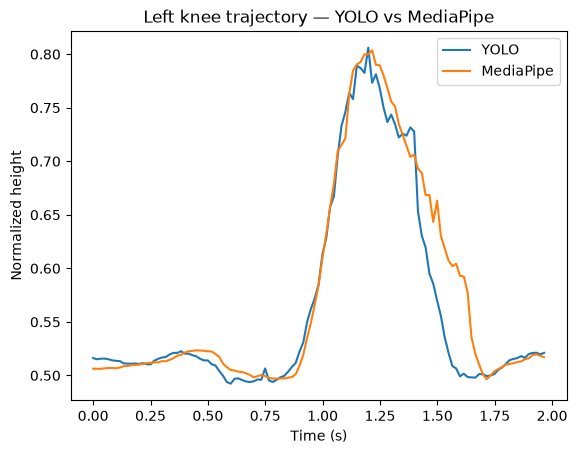

In [3]:
yolo_hip = df_yolo[df_yolo["keypoint"] == "right_knee"]
mp_hip = df_mp[df_mp["keypoint"] == "right_knee"]

plt.plot(
    yolo_hip["time"],
    1 - yolo_hip["y"],
    label="YOLO"
)

plt.plot(
    mp_hip["time"],
    1 - mp_hip["y"],
    label="MediaPipe"
)

plt.xlabel("Time (s)")
plt.ylabel("Normalized height")
plt.title("Left knee trajectory — YOLO vs MediaPipe")
plt.legend()

plt.show()

### Ankle

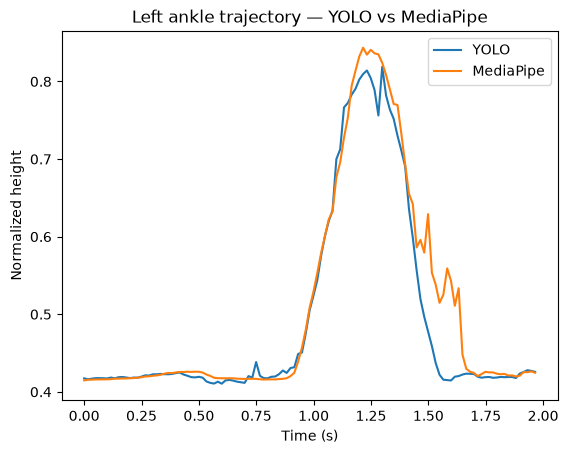

In [4]:
yolo_hip = df_yolo[df_yolo["keypoint"] == "right_ankle"]
mp_hip = df_mp[df_mp["keypoint"] == "right_ankle"]

plt.plot(
    yolo_hip["time"],
    1 - yolo_hip["y"],
    label="YOLO"
)

plt.plot(
    mp_hip["time"],
    1 - mp_hip["y"],
    label="MediaPipe"
)

plt.xlabel("Time (s)")
plt.ylabel("Normalized height")
plt.title("Left ankle trajectory — YOLO vs MediaPipe")
plt.legend()

plt.show()

### Shoulder

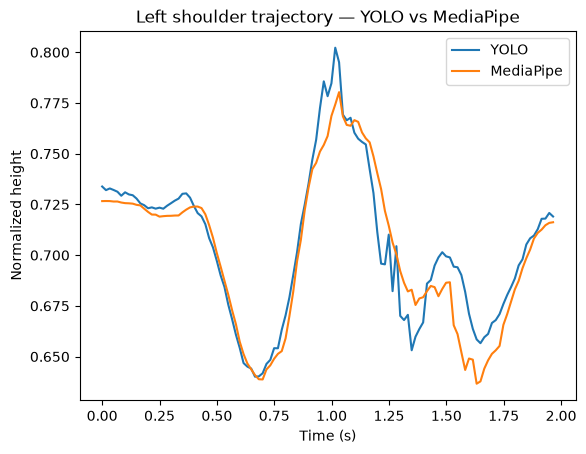

In [5]:
yolo_hip = df_yolo[df_yolo["keypoint"] == "right_shoulder"]
mp_hip = df_mp[df_mp["keypoint"] == "right_shoulder"]

plt.plot(
    yolo_hip["time"],
    1 - yolo_hip["y"],
    label="YOLO"
)

plt.plot(
    mp_hip["time"],
    1 - mp_hip["y"],
    label="MediaPipe"
)

plt.xlabel("Time (s)")
plt.ylabel("Normalized height")
plt.title("Left shoulder trajectory — YOLO vs MediaPipe")
plt.legend()

plt.show()

## Video monitoring


Yolo automatically creates the annotated video for you and saves it in a runs/pose folder. For those who do not want to run all the repo, I pushed the annotated video in assets/yolo_prediction. If you watch it, you will see the model strugling with the left shoulder between 1s and 1.5s.

MediaPipe does not provides the annotated video automatically, but it still provides drawing tools. The script below makes the annotated video using them.

In [6]:
output_path = "../assets/mp_prediction/backflip.mov"
video_path = "../assets/backflip.mov" 

# open original video
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# create output video
fourcc = cv2.VideoWriter_fourcc(*"mp4v") # codec
writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# MediaPipe drawing utilities
drawing = mp.tasks.vision.drawing_utils
connections = (mp.tasks.vision.PoseLandmarksConnections.POSE_LANDMARKS) # lines
NormalizedLandmark = (mp.tasks.components.containers.NormalizedLandmark) # points

frame_index = 0

while True:
    success, frame = cap.read()

    if not success:
        break

    # get landmarks for this frame
    frame_data = df_mp[df_mp["frame"] == frame_index]

    if len(frame_data) == 33:

        # rebuild mp landmarks
        pose = [
            NormalizedLandmark(
                x=row.x,
                y=row.y,
                z=row.z,
                visibility=row.visibility,
                presence=row.presence
            )
            for row in frame_data.itertuples()
        ]

        # draw skeleton
        drawing.draw_landmarks(image=frame, landmark_list=pose, connections=connections)

    # save frame
    writer.write(frame)

    frame_index += 1

cap.release()
writer.release()

Here are screenshots of Yolo's video:

![yolo 1](../assets/yolo__prediction/screenshot1.png)
![yolo 2](../assets/yolo__prediction/screenshot2.png)

and MediaPipe's video:

![mp 1](../assets/mp_prediction/screenshot1.png)
![mp 2](../assets/mp_prediction/screenshot2.png)

I personally think Yolo looks better but MediaPipe provides more landmarks and is more accurrate overall.